# Where do Black Holes come from?

## A guide to stars and stellar evolution

##### This is a jupyter notebook. It allows you to write down your thoughts, show images and videos, and run code interactively. Try changing things and see what happens!

In [1]:
# Import external packages, and supply settings used throughout the tutorial - you can ignore this cell
import numpy as np
import h5py as h5
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import AppLayout, FloatSlider, Play, IntSlider, widgets, HBox, VBox, interact, interactive
from IPython.display import YouTubeVideo
from scripts.BHSummerSchoolUtils import printCompasDetails, get_data, make_interactive_widget #, make_HR_diag

%matplotlib widget

# 1. How do stars form?

## Many Black Holes come from stars, so to understand Black Holes we have to understand stars. But not all stars can produce Black Holes. 

## To understand which kinds of stars can become Black Holes, we need to understand how stars work, and how they evolve throughout their lives.

### ❓ Q: What is a star?  

 <img src="data/images/lmc_smc.jpg" alt="Drawing" style="width: 800px;"/>

## A star forms when a big cloud of interstellar gas collapses under its own weight & gravity. 

### - The gas is composed primarily of Hydrogen, with maybe a bit of Helium as well. We sometimes abbreviate Hydrogen to just $H$, and Helium to just $He$.

### - The cloud molecules compress more and more, increasing in temperature and pressure. 

### The video below shows a simulation of stars forming in the collapse of a gas cloud.


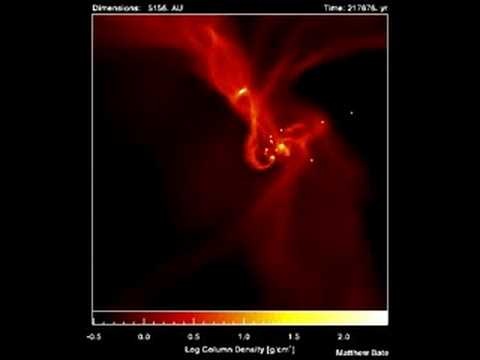

In [2]:
YouTubeVideo('YbdwTwB8jtc', width=800, height=500)

## When the temperature and pressure become high enough, the Hydrogen starts to fuse together. 

## This is called _nucleosynthesis_, and the star is "born" when nucleosynthesis starts. 

 <img src="data/images/PeriodicTable-Detail-Types-batlow-sInk-Fabio-Crameri.png" alt="Drawing" style="width: 800px;"/>

## As some of you may know, a Hydrogen atom is the simplest atom. It is composed of just a proton in the nucleus, with an electron around it. 

### - But in the hot, high pressure cores of stars, the electrons are unbound, so Hydrogen is just a proton. 

### - When the Hydrogens (or protons) start smashing together, you create Helium. Helium is 2 protons and 2 neutrons (since we are ignoring the electrons here). 

### ❓ Q: What are the differences between a proton, a neutron, and an electron?  

 <img src="data/images/h_he_atoms.png" alt="Drawing" style="width: 500px;"/>

## To form $He$ in a star, you need 4 $H$ to fuse together. This process is _nuclear fusion_.

<img src="data/images/Proton-proton_reaction_chain.jpg" alt="Drawing" style="width: 800px; "/>

## The main idea here is that if you start with 4 $H$ and you keep smashing them together, you end up with $He$, and some extra energy.

## Protons and neutrons have nearly the same mass, so we can think about a $H$ atom having one “mass” (or “atomic mass unit” amu) and $He$ having a mass of 4 amu. 

### - But if we are more careful, the masses don’t exactly line up...

In [ ]:
# Calculate the mass difference in the reaction, using masses defined in amu

mass_Hydrogen = 1.00784
mass_Helium = 4.002602
mass_Positron = 5.48756e-4

mass_difference = (4*mass_Hydrogen) - (mass_Helium + 2*mass_Positron)
print("The difference in mass before and after is {:.4f} amu".format(mass_difference))

## Where did the mass go? Mass is supposed to be conserved right?

### - The answer is that sometimes mass _by itself_ is not conserved, but mass and energy together are. 

### - Here, the missing mass is actually being converted into energy (via the Gamma Rays and Neutrinos)

### - To calculate how much energy was released, we need a way to convert between mass and energy.

<img src="data/images/emc2.jpg" alt="Drawing" style="width: 500px; "/>

In [ ]:
# Calculate the energy released in the reaction. Use cgs units - centimeters, grams, seconds

grams = 1.67377e-24            # g per amu
m = mass_difference * grams    # mass difference above, converted to g
c = 2.99792e10                       # speed of light, in cm / s

E = m * c**2                   # energy in ergs

print("The energy released in the reaction is {:.3e} ergs".format(E))
print()
print("By comparison, if you were to drop a 10g pin from a height of 1 meter, it would hit the ground with an energy of 1 million ergs, or 1e6 ergs.")

## This seems like a really small amount, but there's so much material lying around in the center of the sun that this reaction happens _a lot_.

### - Much of this energy is released as photons. Photons try to move in a straight line to escape the star, but in the dense core, they can easily get intercepted by other atoms. 

### - Photons can be absorbed and re-emitted many millions of times before they finally escape the star. 

<img src="data/images/thesurfaceofthesun.jpg" alt="Drawing" style="width: 800px; "/>

#### Fun fact! Because of all the bouncing around and re-directing that a photon goes through, its takes between several thousand and several million years for a photon to escape from the sun! 

#### If it were unimpeded, it would take only a few seconds.

## Since photons carry momentum, this momentum pushes on the atoms that intercept them, creating an outward pressure. 

### - This pressure is what keeps the star from collapsing under its own weight. 

### - Without nuclear reactions producing photons, energy, and pressure, the star would continue to contract. 

<img src="data/images/hydrostat_equil.jpg" alt="Drawing" style="width: 600px; "/>

## So now we know how stars remain in balance, or what we call _hydrostatic equilibrium_, at any given moment in time

### - But what happens over the course of their lifetimes? 

### - How do they evolve? 


 <img src="data/images/Diagram_of_the_life_of_Sun-like_stars.jpg" alt="Drawing" style="width: 1000px;"/>

## Stars age at different rates. The more _massive_ star star, the faster it ages, and the shorter its life will be.

### - Stars can lose mass through _winds_. More massive stars have higher winds, so they will lose more mass by the end of their lives.

### - Stars will also grow - a lot! Stars go through various stages of expansion (and also contraction), and will in some cases grow to be 1000x their size when they were born.

In [ ]:
# Make plot of the evolution of the mass and radius with time

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10, 5))
axs = axes.flatten()
fig.canvas.header_visible = False
colormap = mpl.cm.rainbow

for index in range(10):

    # Pick out the correct data file
    data = get_data(index)

    # Extract the data from this file
    mass = data['Mass(1)'][()]
    radius = data['Radius(1)'][()]
    time = data['Time'][()]
    stellar_type = data['Stellar_Type(1)'][()]
    record_type = data['Record_Type'][()]

    # Create a mask, to show only the interesting parts of the data
    mask = record_type == 4 
    mask &= time < 1e3 
    mask &= stellar_type < 10

    # Set the color of the line
    color=colormap(index/10)
    
    # First plot: Mass vs Time
    ax = axs[0]
    ax.plot(time[mask], mass[mask], color=color, lw=3)
    ax.set_xlabel('Time [Myr]')
    ax.set_ylabel('Mass [$M_\odot$]')
    ax.set_ylim(-0.5, 55)
    ax.set_title("Star Mass vs Age")
    ax.set_yticks(np.linspace(0, 50, 6), minor=False)
    ax.set_yticks(np.linspace(0, 50, 11), minor=True)
    ax.grid(True)
    
    # Second plot: Mass vs Time, log scale
    ax = axs[1]
    ax.plot(time[mask], mass[mask], color=color, lw=3)
    ax.set_xlabel('Time [Myr]')
    ax.set_ylabel('Mass [$M_\odot$]')
    ax.set_xscale('log')
    ax.set_xlim((.1, 200))
    ax.set_ylim(-0.5, 55)
    ax.set_title("Star Mass vs Age, using $\log$")
    ax.set_yticks(np.linspace(0, 50, 6), minor=False)
    ax.set_yticks(np.linspace(0, 50, 11), minor=True)
    ax.grid(True)
    
    # Third plot: Radius vs Time
    ax = axs[2]
    ax.plot(time[mask], radius[mask])
    ax.plot(time[mask], radius[mask], color=color, lw=3)
    ax.set_xlabel('Time [Myr]')
    ax.set_ylabel('Radius [$R_\odot$]')
    ax.set_title("Star Radius vs Age")
    ax.grid(True)

    # Fourth plot: Radius vs Time, log scale
    ax = axs[3]
    ax.plot(time[mask], radius[mask])
    ax.plot(time[mask], radius[mask], color=color, lw=3)
    ax.set_xlabel('Time [Myr]')
    ax.set_ylabel('Radius [$R_\odot$]')
    ax.set_xscale('log')
    ax.set_xlim((.1, 200))
    ax.set_yscale('log')
    ax.set_title("Star Radius vs Age, using $\log$")
    ax.grid(True)
    
    
fig.tight_layout()    

## Do you understand all of these plots? What are the units being used?

## What is the difference between the two plots in the top row? Which one is clearer? What about the bottom row?


## In reality, we don't always know the mass or radius of a star just by looking at it. One of the most common ways we study stars is by instead measuring their _Luminosity_ (or Brightness) and their _Temperature_. These are quantities that can be measured in a fairly straightforward way using telescopes with even very basic filters. 

## When we plot the Luminosity ($L$) vs the Effective Temperature ($T_{eff}$), we create a [Hertzsprung-Russell](https://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram) diagram, or an HR diagram for short. 

 <img src="data/images/hr_diag.png" alt="Drawing" style="width: 800px;"/>


## In the code below, we will make an HR diagram, and fill it with a bunch of simulated stars. As we increase the age, we will see how they jump through the diagram.

In [ ]:
## Create HR diagram that evolves in time
def make_HR_diag(fig, ax):

    # Create and stylize figure 
    fig.canvas.header_visible = False
    ax.set_title("Hertzsprung-Russel diagram") 
    xlim = (1e3, 1e5) 
    ylim = (1e-1, 1e7) 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_xaxis()
    ax.set_xlabel(r'Effective Temperature [T/K]')
    ax.set_ylabel(r'Luminosity [$L/L_\odot$]')
    ax.set_xlim(xlim[::-1])
    ax.set_ylim(ylim)
    
    #Add lines of const radii
    for R in np.logspace(-2, 5, 7):
        exp = "{:.2e}".format(R)
        T_K = np.logspace(3, 7, 41)  # in K
        T = T_K / 6e3  # Tsol=6e3K
        def get_L(t):  # assumes K
            return R * R * t * t * t * t
        L = get_L(T)
        ax.plot(T_K, L, '--k', alpha=0.2)
        # Plot the Rsol text at the bottom and right
        Lbot = ylim[0] * 2  
        Trgt = xlim[0] * 2  
        Tbot = np.sqrt(np.sqrt(Lbot / (R * R))) * 6e3  # K
        Lrgt = get_L(Trgt / 6e3)
        alpha = 0.4
        s = "$10^{{{exp}}}R_\odot$".format(exp=exp[-3] + exp[-1])
        if (Tbot > Trgt) and (Tbot < xlim[1]):
            ax.text(x=Tbot, y=Lbot, s=s, alpha=alpha)
        elif (Lrgt > Lbot) and (Lrgt < ylim[1]):
            ax.text(x=Trgt, y=Lrgt, s=s, alpha=alpha)
    

    fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=100), cmap=colormap), ax=ax, label=r"$M \; [M_\odot]$")
    
def get_star_properties(max_time, N_timesteps, logTime, N_simulations):
    
    colormap = mpl.cm.rainbow
    masses = []
    
    N_timesteps = int(N_timesteps)
    # Collect data at the desired timesteps
    Lum =  np.zeros((N_simulations, N_timesteps)) 
    Teff = np.zeros((N_simulations, N_timesteps)) 
    if logTime:
        timesteps = np.logspace(-2, np.log10(max_time), N_timesteps)
    else:
        timesteps = np.linspace(0, max_time, N_timesteps)
    for idx_star in range(N_simulations):
        data = get_data(idx_star, isCoarse=False)
        record_type = data['Record_Type'][()]
        stellar_type = data['Stellar_Type(1)'][()]
        mass = data['Mass(1)'][()][0]
        masses.append(mass)
        mask = (record_type == 4) & (stellar_type < 7)
        Lum[idx_star, :]  = np.interp(timesteps, data['Time'][()][mask], data['Luminosity(1)'][()][mask], right=0.01)
        Teff[idx_star, :] = np.interp(timesteps, data['Time'][()][mask], data['Teff(1)'][()][mask], right=0.01)
    colors = [colormap(mass/100) for mass in masses]
    return Lum, Teff, timesteps, colors

In [ ]:
### USER SETTINGS: adjust these as you like

max_time = 14000 # Myr
N_timesteps = 1e6 
logTime = True
N_simulations = 250

# This line may take a while to run, depending on the settings you've chosen
Lum, Teff, timesteps, colors = get_star_properties(max_time, N_timesteps, logTime, N_simulations)

In [ ]:

fig, ax = plt.subplots(figsize=(8,  5))
make_HR_diag(fig, ax) # Add the background of an HR diagram

def construct_plot(fig, ax, plot_static_HR, add_background_cluster, which_cluster, speed):
    if add_background_cluster:
        cluster = ["NGC6362", "NGC104", "M13"][which_cluster]
        # Overplot with NCG6362
        image = plt.imread('data/images/{}_HR.png'.format(cluster))
        im = ax.imshow(image, extent=[0, 1, 0, 1], aspect='auto', transform=ax.transAxes)
        ax.set_title("Hertzsprung-Russel diagram, for {}".format(cluster)) 
    
    if plot_static_HR:
        ax.scatter(Teff[:,0], Lum[:,0], color=colors)
        return fig
    else:
        def update_func(change):
            itime = int(change.new)
            txt_str = "T={:.2f} Myr".format(timesteps[itime])
            txt = plt.text(x=0.1, y=0.25, s=txt_str, transform=ax.transAxes)
            points = plt.scatter(Teff[:,itime], Lum[:,itime], color=colors)
            fig.canvas.draw()
            fig.canvas.flush_events()
            txt.remove()
            points.remove()

        return make_interactive_widget(fig, update_func, smax=N_timesteps, step=N_timesteps/100, speed=speed)
    
### DON'T EDIT ABOVE THIS LINE
#######################

### SET THESE VALUES AS YOU LIKE
plot_static_HR = False
add_background_cluster = True
which_cluster = 0 # Choose between 0, 1, and 2
speed = 1

construct_plot(fig, ax, plot_static_HR, add_background_cluster, which_cluster, speed)

# 2. Which stars form Black Holes

## Now we've seen how stars of different masses evolve. But how do they end their lives?

 <img src="data/images/remnant_mass_func.png" alt="Drawing" style="width: 600px;"/>

 From Heger, Mueller, & Mandel (2024)

## If this plot looks confusing to you, that's kind of the point. It's confusing to us, too! 

### This is an ongoing field of research, but there are a few things we understand fairly well.

### Stars less than roughly 8x the mass of the sun (or 8 $M_\odot$) are considered "low-mass" stars. They will slowly lose their outer envelopes throughout their whole lives, until all that's left is the hot core of the star. Like an ember after a fire, this core will simply spend its final days cooling down.

### By contrast, stars greater than ~8 $M_\odot$, the massive stars, will continue burning new elements in their core until they can't go any further. These stars end their lives in bright _Supernova_ explosions. These explosions are so luminous, that they can be seen easily in distant galaxies. The few times in history that they have occurred in our galaxy, the Milky Way, they appeared like a bright star that could be seen in broad daylight.

## Unfortunately, supernovae are very complicated to simulate

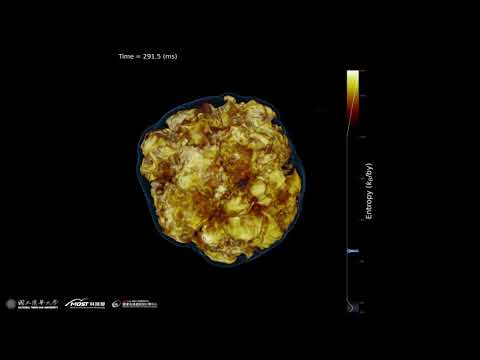

In [3]:
YouTubeVideo('bxKwMGgAkdQ', width=800, height=500)

## The important thing to remember is that only massive stars explode as supernovae, and after the explosion you end up with _either_ a Black Hole or a _Neutron Star_. 

### - A neutron star is the densest possible form of matter: a teaspoon of neutron star matter weighs more than a mountain!

### - But during some supernovae, the neutron star can keep growing. And if it gets too big, ~2 $M_\odot$, it will collapse into the other thing denser than a neutron star: a black hole. 

### ❓ Q: What are 3 things you didn't understand about this session?